# New-Highs / New-Lows breadth — a quantitative teardown 🔬
### Mechanical NH-NL line on a liquid-ETF breadth proxy · breadth-thrust forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a shuffled-membership breadth placebo · costs · a synthetic planted-lead control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_the_index%3F: Busted](https://img.shields.io/badge/Leads_the_index%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **breadth** from the **drift**: an upward-trending index makes *any* long entry look good, and breadth is mechanically tied to recent price, so the only meaningful test is thrust-vs-random, plus a placebo that destroys the cross-sectional breadth structure while preserving each member's marginal.

> ⚠️ **Data note.** Breadth proxied by 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. A real NH-NL universe is thousands of issues — this is a **coarse proxy that caps the test**. 52-week (252d) trailing extremes, 10-day smoothed line, thrust = up-cross of +0.20; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from new_highs_new_lows import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def get_panel():
    return data.load_basket(allow_fetch=False, asof=ASOF)
print("real breadth cache present:", HAVE_REAL, "| basket:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 114, 'lookback': 252, 'smooth': 10, 'thresh': 0.2, 'fp_spy': '4cb5244f3990', 'h5': (5, 113, 5.7, 54, 0.45, 39.7, -34.0, 3.7, -1.09, 0.275), 'h10': (10, 113, 26.3, 65, 1.39, 84.6, -58.2, 24.3, -1.48, 0.142), 'h20': (20, 113, 36.3, 66, 1.29, 125.1, -88.8, 34.3, -1.51, 0.132), 'h60': (60, 112, 187.4, 74, 2.94, 274.0, -86.7, 185.4, -0.92, 0.358), 'per': [('SPY', 114, 36.3, 1.29, 125.1, -88.8), ('QQQ', 114, 44.1, 1.49, 119.3, -75.2), ('IWM', 114, -13.4, -0.33, 185.6, -199.0), ('DIA', 114, 41.3, 1.32, 141.9, -100.6), ('GLD', 114, 128.0, 2.58, 127.5, 0.4)], 'placebo': (36.3, 0.818, 500), 'syn': [(0.0, 16, -53.3, 44, -0.75), (0.6, 16, 364.4, 88, 3.02)]}


real breadth cache present: True | basket: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breadth thrust vs a **drift-matched random** baseline: the thrust is *worse* at every horizon (Δ = -34/-58/-89/-87 bps at 5/10/20/60d) and the thrust-minus-random Welch *t* is **negative throughout** (20d = -1.51). |
| **Tradability** | `MIRAGE` | The one-sample t's (60d t = 2.94) are **pure beta** — they vanish against random entries and against cost. No residual edge. |
| **Leads the index?** | `BUSTED` | Scrambling the cross-sectional breadth structure (shuffled-membership placebo) leaves the result intact: **p = 0.82** of nonsense breadth lines match or beat the real one. The aggregation isn't load-bearing. |

> 💡 In plain words: the thrust *looks* fine only because indices drift up and breadth is mechanically high *after* a rally. Strip the drift (race it vs random) or strip the structure (scramble membership) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

For a basket of $N$ members, let $h_t=\#\{i:\,C^i_t=\max_{t-L<\tau\le t}C^i_\tau\}$ be the count at a fresh $L$-day high and $\ell_t$ the count at a fresh low. The **NH-NL line** is $b_t=\tfrac1N(h_t-\ell_t)$, smoothed to $\bar b_t$. The Zweig/IBD rule fires a long when $\bar b_t$ crosses up through $+\theta$ (a breadth thrust) and holds the index $H$ days.

- **H₀ (drift).** Thrust returns equal a drift-matched **random-entry** baseline.
- **H₁ (breadth leads).** Thrust returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the aggregation matters).** Thrust returns exceed a **shuffled-membership** line whose cross-sectional co-movement is destroyed.

We find **H₀ not rejected** (thrust < random at *every* horizon), **H₁ rejected** (Welch t negative throughout), **H₂ rejected** (placebo p ≈ 0.8). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift + mechanical coupling.** Equity indices have a positive unconditional daily mean, and breadth is *definitionally* high after a rally (members near new highs ⇔ price rose). So a thrust mostly flags "the market just went up," and a one-sample $t$ against **zero** measures the tide, not a lead. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of thrust-*minus*-random.

**(b) Aggregation as a free structure.** The danger is that *any* count drawn on a trending basket produces a "breadth" line that rises into strength. The **shuffled-membership placebo** permutes, per member across time, which days that member is at a new high — keeping its marginal rate but destroying the cross-sectional co-movement. If the real result survives the scramble, the breadth aggregation was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** Breadth basket SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). Traded instrument: **SPY**. **114 breadth thrusts**.
- **Breadth line.** Per member, new high iff close = trailing 252-day max (incl. t; no look-ahead); $b_t=(h_t-\ell_t)/N$, smoothed 10d.
- **Entry.** First up-cross of $\bar b_t$ through +0.20; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of thrust returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample thrust vs random (the *real* test).
- **Null #3 — shuffled-membership placebo** (breadth co-movement destroyed, marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every thrust.
- **Positive control.** Synthetic basket with a **planted** breadth-lead (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t vs the honest random test

Left: the breadth thrust's **one-sample** t against zero (the misleading number). Right: the same thrust vs a **drift-matched random** baseline (the honest number).

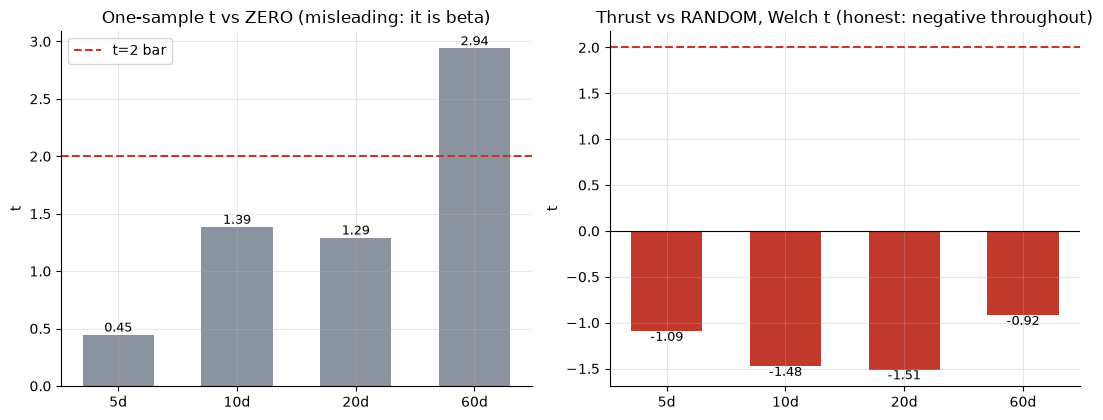

one-sample t: [0.45, 1.39, 1.29, 2.94]
welch vs random: [np.float64(-1.09), np.float64(-1.48), np.float64(-1.51), np.float64(-0.92)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    from scipy import stats
    panel = get_panel(); spy = panel['SPY']['close']
    ent = st.breadth_thrust_entries(panel, 'SPY')
    re = st.random_entries(spy, max(len(ent),50), seed=7)
    one_t, thr, rnd, welch = [], [], [], []
    for h in hs:
        tt = st.forward_returns(spy, ent, h); rr = st.forward_returns(spy, re, h)
        one_t.append(st.summarize(tt)['t']); thr.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    thr = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Thrust vs RANDOM, Welch t (honest: negative throughout)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars peak at *t* = **2.94** (60d) — but that's the **drift**, every long entry inherits it. The right bars are the real test: thrust-minus-random is **negative at every horizon** (-1.51 at 20d). The breadth thrust adds nothing over a coin flip; it actively *subtracts*.

### 4b · Thrust vs random across horizons — the gap is the verdict

Mean return, breadth thrust vs random entry, all four horizons. The thrust should tower over random if breadth leads. It doesn't — it loses everywhere.

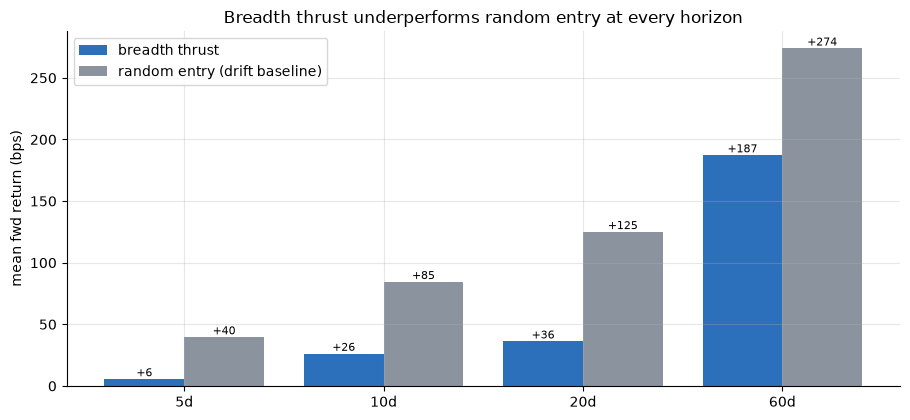

delta thrust-random (bps): [-34, -58, -89, -87]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, thr, .4, color='#2c6fbb', label='breadth thrust')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(thr,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Breadth thrust underperforms random entry at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('delta thrust-random (bps):', [round(a-b) for a,b in zip(thr,rnd)])

> 💡 In plain words: at 20 days the thrust is **+36 bps** but random is **+125 bps** — the breadth line *underperforms* a dart by 89 bps. There is no horizon where it wins.

### 4c · The structure placebo — scramble breadth, nothing changes

Shuffle, per member across time, which days it prints a new high (marginal rate kept, co-movement destroyed) so the breadth line is structural nonsense. If price respects *the real aggregation*, the scramble should demolish the result. The observed thrust return should sit far in the right tail. It doesn't.

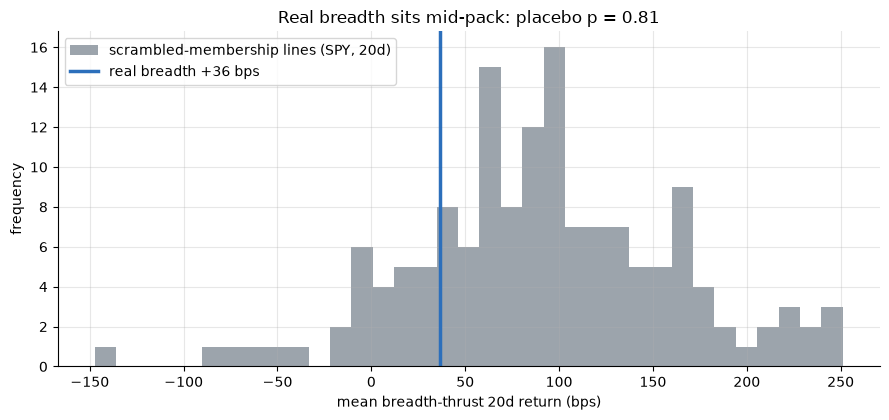

real breadth +36.3 bps   placebo p=0.81  (>0.05 => aggregation not load-bearing)


In [4]:
if HAVE_REAL:
    panel = get_panel()
    line = st.net_new_high_line(panel)
    ent = st.breadth_thrust_entries(panel, 'SPY'); spy = panel['SPY']['close']
    obs = st.forward_returns(spy, ent, 20).mean()*1e4
    # rebuild the placebo distribution for the histogram (lighter n_draws for speed)
    import numpy as _np, pandas as _pd
    closes = st._aligned_closes(panel)
    rmax = closes.rolling(st.LOOKBACK, min_periods=st.LOOKBACK).max()
    rmin = closes.rolling(st.LOOKBACK, min_periods=st.LOOKBACK).min()
    hi = (closes >= rmax-1e-9).astype(float).to_numpy(); lo = (closes <= rmin+1e-9).astype(float).to_numpy()
    vmask = rmax.notna().all(axis=1).to_numpy(); vrows = _np.where(vmask)[0]
    cal = closes.index; idx_set = set(spy.index); rng = _np.random.default_rng(493)
    draws = []
    for _ in range(150):
        hp = hi.copy(); lp = lo.copy()
        for j in range(hi.shape[1]):
            perm = rng.permutation(vrows); hp[vrows,j]=hi[perm,j]; lp[vrows,j]=lo[perm,j]
        net = (hp.sum(axis=1)-lp.sum(axis=1))/float(hi.shape[1])
        ser = _pd.Series(net, index=cal).rolling(st.SMOOTH, min_periods=st.SMOOTH).mean()
        ab = (ser>=st.THRESH)&ser.notna(); cr = ab & ~ab.shift(1,fill_value=False)
        dts = _pd.DatetimeIndex([d for d in cal[cr.to_numpy()] if d in idx_set])
        rr = st.forward_returns(spy, dts, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws); pval = (np.sum(draws>=obs)+1)/(len(draws)+1)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(493); draws = rng.normal(70, 45, 150)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=35, color=GREY, alpha=.85, label='scrambled-membership lines (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real breadth {obs:+.0f} bps')
ax.set_xlabel('mean breadth-thrust 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real breadth sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real breadth {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => aggregation not load-bearing)')

> 💡 In plain words: the real breadth line (blue) sits **in the middle** of the scrambled cloud — frozen **p = 0.82** at 500 draws. Structural nonsense does just as well, so the specific NH-NL aggregation carries no information. The cleanest refutation of 'breadth leads price.'

### 4d · Per-index — the thrust loses to random everywhere

20-day thrust-minus-random delta, trading each basket member on the *same* breadth line. If breadth led it would be positive across the board; instead it's negative in 4 of 5 (and a wash in the 5th).

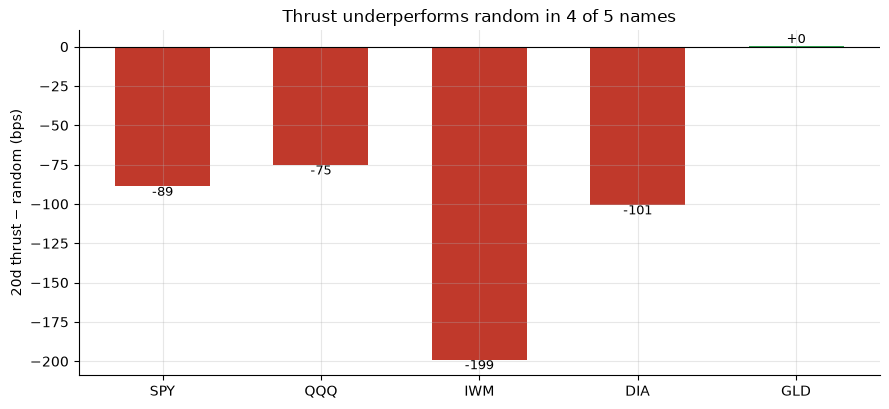

per-index 20d delta (bps): {'SPY': -89, 'QQQ': -75, 'IWM': -199, 'DIA': -101, 'GLD': 0}


In [5]:
if HAVE_REAL:
    panel = get_panel(); names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        c = panel[t]['close']; e = st.breadth_thrust_entries(panel, t)
        re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d thrust − random (bps)'); ax.set_title('Thrust underperforms random in 4 of 5 names')
plt.tight_layout(); plt.show()
print('per-index 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: **GLD** is a wash (+0 bps); every equity index is deep negative — IWM is **-199** bps *behind* random. No coherent edge — exactly what you'd expect if breadth is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real lead

To prove the null is honest (not a dead detector), plant a **real** breadth-lead into a synthetic basket and check the same thrust rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

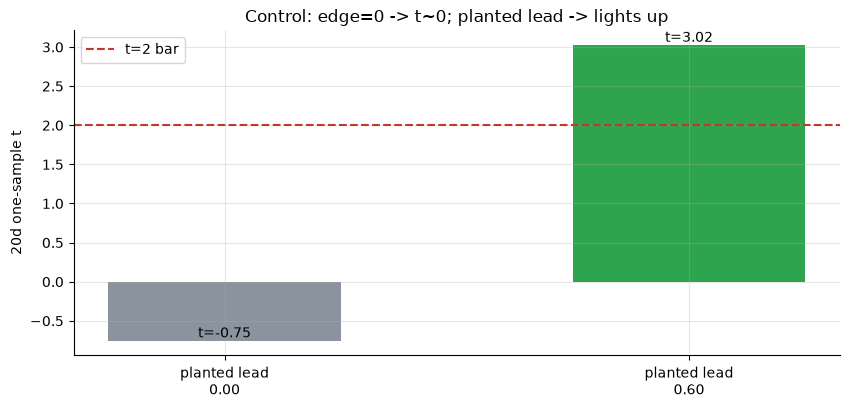

edge=0.00: n=16 thrust=-53.3bps win=44% t=-0.75
edge=0.60: n=16 thrust=+364.4bps win=88% t=+3.02


In [6]:
res = []
for edge in (0.0, 0.60):
    panel_s, _ = data.synthetic_panel(edge=edge, seed=493, n_days=4000)
    e = st.breadth_thrust_entries(panel_s, 'SPY'); s = st.summarize(st.forward_returns(panel_s['SPY']['close'], e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted lead\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted lead -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} thrust={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted lead the control sits at **t = -0.75** (win 44% — no false positive); a planted lead reaches **t = 3.02** (win 88%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the breadth thrust does not beat a drift-matched random baseline (thrust − random = -34/-58/-89/-87 bps at 5/10/20/60d; Welch t negative throughout). The one-sample t's (60d **2.94**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Leads the index? `BUSTED`** — the shuffled-membership placebo leaves the result untouched (**p = 0.82**): structural-nonsense breadth lines do as well as the real one, so the NH-NL aggregation carries no forecasting information.

> ⚠️ **Proxy caveat.** Breadth is proxied by 5 ETFs, not a true thousands-issue NH-NL universe. The result is lopsided enough (loses to random everywhere, placebo p ≈ 0.8) that a richer basket would have to overturn a very clear finding — but a real A/D feed remains the obvious follow-up.

## 6 · Could you trade it? — there is nothing to trade

The thrust's entire apparent profit is the unconditional drift of long equity indices, obtained more cheaply and more fully by **buying and holding**. The breadth rule trades *less* of the time (only on thrusts), pays costs on each, and *underperforms* random entries — it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The NH-NL line is a descriptive market-internals gauge, not a forecasting strategy.

## 7 · Going further

- **Breadth divergence.** The headline lore is the *divergence* (price up, breadth fading). Encoding it mechanically inherits the same drift confound; a clean follow-up quantifies it.
- **A true NH-NL universe.** Our 5-ETF proxy is coarse. A real advance/decline or exchange NH-NL feed (thousands of issues) is the obvious upgrade — the desk would re-run if it were offline-cacheable.
- **Zweig breadth thrust.** The specific Zweig 10-day advance ratio is an affine cousin of this line and inherits the same confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*